## 사용자 맞춤형 패션 스타일 추천 시스템
본 노트북은 샘플 데이터(28,465행)를 바탕으로 사용자의 개인적 특성과 취향을 분석하여 최적의 패션 스타일을 제안하는 로직을 담고 있습니다.

1. 주요 기능
- 입력 데이터: 성별, 연령, 퍼스널 컬러, 설문 질문별 답변
- 분석 로직: 사용자 입력값과 데이터셋 간의 유사도/매칭 점수 계산
- 출력 결과: 추천 스타일 Top 3 (형식: 이미지 파일명/스타일/시대)

2. 데이터 특이사항
- 연령 데이터: 원본 데이터셋의 `user.age` 컬럼은 1(20대), 2(30대), 3(40대), 4(50대)로 구성되어 있으며, 이를 변환하여 연령대 필터링에 활용합니다.

3. 향후 확장 계획
- 추천된 스타일 결과를 바탕으로 무신사(Musinsa) 및 지그재그(Zigzag) 딥링크 연동
- 필터링 및 검색 자동화를 통해 실질적인 상품 구매 페이지로 연결

In [ ]:
# 압축을 풀 폴더 생성 및 해제
!mkdir -p /content/sample_data/fashion_data
!unzip /content/sample_data/Sample.zip -d /content/sample_data/fashion_data

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: /content/sample_data/fashion_data/Sample/02.라벨링데이터/2.validation/woman/1980/T_12042_80_powersuit_W_185052.json  
  inflating: /content/sample_data/fashion_data/Sample/02.라벨링데이터/2.validation/woman/1980/T_12042_80_powersuit_W_205080.json  
  inflating: /content/sample_data/fashion_data/Sample/02.라벨링데이터/2.validation/woman/1980/T_12074_80_powersuit_W_035628.json  
  inflating: /content/sample_data/fashion_data/Sample/02.라벨링데이터/2.validation/woman/1980/T_11680_80_powersuit_W_209850.json  
  inflating: /content/sample_data/fashion_data/Sample/02.라벨링데이터/2.validation/woman/1980/T_11899_80_bodyconscious_W_103277.json  
  inflating: /content/sample_data/fashion_data/Sample/02.라벨링데이터/2.validation/woman/1980/T_11915_80_bodyconscious_W_025089.json  
  inflating: /content/sample_data/fashion_data/Sample/02.라벨링데이터/2.validation/woman/1980/T_11901_80_bodyconscious_W_222773.json  
  inflating: /content/sample_data/fashion_data/Sample/02.라벨링데이터/2.validation/

In [ ]:
import os

data_dir = '/content/sample_data/fashion_data'
files = os.listdir(data_dir)
print(f"전체 파일 개수: {len(files)}")
print("파일 목록 샘플:", files[:10]) # 처음 10개만 출력

전체 파일 개수: 1
파일 목록 샘플: ['Sample']


In [ ]:
import json
import pandas as pd
from tqdm.notebook import tqdm  # 진행률 표시 바

def integrate_fashion_data(base_path):
    all_rows = []

    # 모든 하위 폴더 순회
    json_files = []
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith('.json'):
                json_files.append(os.path.join(root, file))

    print(f"총 {len(json_files)}개의 JSON 파일을 찾았습니다. 통합을 시작합니다.")

    # 각 파일을 읽어서 Flatten 후 리스트에 담기
    for file_path in tqdm(json_files, desc="데이터 통합 중"):
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                content = json.load(f)

                # json_normalize로 item, user 등을 한 줄로 펴기
                flat_data = pd.json_normalize(content)
                all_rows.append(flat_data)
        except Exception as e:
            print(f"오류 발생 파일 ({os.path.basename(file_path)}): {e}")

    # 모든 데이터프레임을 하나로 합치기
    if all_rows:
        combined_df = pd.concat(all_rows, ignore_index=True)
        return combined_df
    else:
        return None

# 실행
base_path = '/content/sample_data/fashion_data'
df = integrate_fashion_data(base_path)

# 결과 확인
if df is not None:
    print(f"\n✅ 통합 완료! 총 {len(df)}행의 데이터가 준비되었습니다.")
    display(df.head())
else:
    print("❌ 데이터를 찾지 못했습니다. 경로를 확인해주세요.")

총 28465개의 JSON 파일을 찾았습니다. 통합을 시작합니다.


데이터 통합 중:   0%|          | 0/28465 [00:00<?, ?it/s]


✅ 통합 완료! 총 28465행의 데이터가 준비되었습니다.


,E_id,imgName,item.imgName,item.era,item.style,item.gender,item.survey.Q1,item.survey.Q2,item.survey.Q3,item.survey.Q411,...,user.r_gender,user.age,user.mar,user.job,user.income,user.r_style1,user.r_style2,user.r_style3,user.r_style4,user.r_style5
0,226436,T_12344_80_powersuit_W.jpg,T_12344_80_powersuit_W.jpg,1980,powersuit,W,4,1,3,2,...,2,1,1,5,1,2,2,2,2,2
1,44460,T_11376_80_bodyconscious_W.jpg,T_11376_80_bodyconscious_W.jpg,1980,bodyconscious,W,2,1,3,3,...,2,4,2,1,4,2,1,2,2,2
2,4576,W_03906_80_bodyconscious_W.jpg,W_03906_80_bodyconscious_W.jpg,1980,bodyconscious,W,1,2,4,3,...,2,3,2,1,5,2,1,2,2,2
3,135687,W_05366_80_bodyconscious_W.jpg,W_05366_80_bodyconscious_W.jpg,1980,bodyconscious,W,2,1,2,3,...,2,1,1,4,2,2,2,1,2,2
4,204275,T_12592_80_powersuit_W.jpg,T_12592_80_powersuit_W.jpg,1980,powersuit,W,2,1,2,2,...,2,1,2,4,2,2,2,2,2,2


In [ ]:
print("전체 컬럼 개수:", len(df.columns))

# 추천 로직에 사용할 주요 컬럼들만 필터링
key_columns = [col for col in df.columns if 'Q42' in col or 'age' in col or 'gender' in col]
print("확인된 주요 컬럼 샘플:", key_columns[:10])

전체 컬럼 개수: 41
확인된 주요 컬럼 샘플: ['item.gender', 'item.survey.Q4201', 'item.survey.Q4202', 'item.survey.Q4203', 'item.survey.Q4204', 'item.survey.Q4205', 'item.survey.Q4206', 'item.survey.Q4207', 'item.survey.Q4208', 'item.survey.Q4209']


In [37]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def recommend_fashion(user_input, df):
    # 하드 필터링 1: user_gender와 일치하는 데이터로 필터링
    filtered_df = df[df['item.gender'] == user_input['user_gender']].copy()

    if filtered_df.empty:
        print(f"경고: 성별 '{user_input['user_gender']}'에 해당하는 아이템을 찾을 수 없습니다. 빈 리스트를 반환합니다.")
        return [] # 해당 성별에 아이템 없음

    # 하드 필터링 2: user_age 연령대 필터링
    age_filtered_df = filtered_df[filtered_df['user.age'] == user_input['user_age']].copy()
    if not age_filtered_df.empty:
        filtered_df = age_filtered_df
    else:
        print(f"경고: 연령 '{user_input['user_age']}'에 해당하는 데이터가 부족하여 연령 필터링을 건너뜁니다.")

    sub_df = filtered_df.copy()

    # 사용자 선호도 벡터 초기화 (Q412, Q413, Q4201-Q4216)
    feature_columns = ['Q412', 'Q413'] + [f'Q42{i:02d}' for i in range(1, 17)]
    user_vector_dict = {col: 0.0 for col in feature_columns}

    # Q412(밝기) 및 Q413(따뜻함)의 기본/중립 값 설정
    user_vector_dict['Q412'] = 0.5
    user_vector_dict['Q413'] = 0.5

    # 3. 퍼스널 컬러 매핑: user_pc에 따라 Q412, Q413 조정
    user_pc = user_input['user_pc']
    personal_color_mapping = {
        '봄 라이트': {'Q412': 0.85, 'Q413': 0.85},
        '봄 브라이트': {'Q412': 0.75, 'Q413': 0.75},
        '봄 웜': {'Q412': 0.65, 'Q413': 0.95},
        '여름 라이트': {'Q412': 0.85, 'Q413': 0.15},
        '여름 뮤트': {'Q412': 0.55, 'Q413': 0.35},
        '여름 쿨': {'Q412': 0.65, 'Q413': 0.05},
        '가을 뮤트': {'Q412': 0.55, 'Q413': 0.65},
        '가을 딥': {'Q412': 0.25, 'Q413': 0.75},
        '가을 웜': {'Q412': 0.45, 'Q413': 0.95},
        '겨울 브라이트': {'Q412': 0.65, 'Q413': 0.15},
        '겨울 딥': {'Q412': 0.15, 'Q413': 0.15},
        '겨울 쿨': {'Q412': 0.55, 'Q413': 0.05}
    }

    if user_pc in personal_color_mapping:
        user_vector_dict['Q412'] = personal_color_mapping[user_pc]['Q412']
        user_vector_dict['Q413'] = personal_color_mapping[user_pc]['Q413']

    # 사용자 선호도 벡터 생성 (7가지 질문)
    user_answers = user_input['user_answers']

    # Q3(색상) 연동: user_answers[2]에 따라 Q412 조정
    if len(user_answers) > 2:
        if user_answers[2] == 'A':         # 어두움
            user_vector_dict['Q412'] = 0.1
        elif user_answers[2] == 'B':       # 밝음
            user_vector_dict['Q412'] = 0.9

    # 나머지 6가지 질문을 Q42xx 컬럼에 매핑
    question_to_q42_mapping = {
        0: {'A': ['Q4211'], 'B': ['Q4204']},  # Q1 (TPO)
        1: {'A': ['Q4202'], 'B': ['Q4206']},  # Q2 (전달하고 싶은 분위기)
        # Q3 (인덱스 2)는 Q412에 대해 처리됨
        3: {'A': ['Q4207', 'Q4208'], 'B': ['Q4209']}, # Q4 (체형 커버)
        4: {'A': ['Q4210'], 'B': ['Q4212']},  # Q5 (평소 선호하는 스타일)
        5: {'A': ['Q4203', 'Q4205'], 'B': ['Q4213', 'Q4214']}, # Q6 (도전해보고 싶은 스타일)
        6: {'A': ['Q4215'], 'B': ['Q4216']}, # Q7 (소재/디테일)
    }

    for i, answer in enumerate(user_answers):
        if i in question_to_q42_mapping:
            mapping = question_to_q42_mapping[i]
            cols_to_increment = []
            if answer == 'A':
                cols_to_increment = mapping['A']
            elif answer == 'B':
                cols_to_increment = mapping['B']

            for col in cols_to_increment:
                user_vector_dict[col] += 1.0 # 선택된 속성에 값 누적

    # user_vector_dict를 일관된 인덱싱을 위해 pandas Series로 변환
    user_vector = pd.Series(user_vector_dict)

    # 유사도 계산:
    # 모든 feature_columns가 sub_df에 존재하는지 확인 (없으면 0.0으로 추가)
    for col in feature_columns:
        if col not in sub_df.columns:
            sub_df[col] = 0.0

    # 유사도 계산을 위해 sub_df에서 피처 매트릭스 추출
    item_feature_matrix = sub_df[feature_columns].values

    # 코사인 유사도를 위해 user_vector를 2D 배열로 재구성 (1개 샘플, N개 피처)
    user_feature_vector = user_vector[feature_columns].values.reshape(1, -1)

    # MinMaxScaler 적용
    scaler = MinMaxScaler()

    # item_feature_matrix에 스케일러를 fit_transform하고, user_feature_vector에는 transform만 적용
    scaled_item_feature_matrix = scaler.fit_transform(item_feature_matrix)
    scaled_user_feature_vector = scaler.transform(user_feature_vector) # 학습된 스케일러로 사용자 벡터 변환

    # 사용자 벡터와 각 아이템 벡터 간의 코사인 유사도 계산
    similarities = cosine_similarity(scaled_user_feature_vector, scaled_item_feature_matrix)[0]

    # 유사도 점수를 sub_df에 추가
    sub_df['similarity_score'] = similarities


    # Q1(선호여부, 1~4) 값이 클수록 추천 점수에 가중치를 더하는 로직
    if 'item.survey.Q4201' in sub_df.columns:
        # Q1 값이 클수록(최대 4) 가산을 주기 위해 0.05 등의 적절한 가중치를 곱해 더합니다.
        sub_df['similarity_score'] += (sub_df['item.survey.Q4201'].fillna(0).astype(float) * 0.05)

    # Q2(계절감)를 1(봄/가을)로 추천(필터링)해주는 로직 (주석 처리)
    # if 'item.survey.Q4202' in sub_df.columns:
    #     sub_df = sub_df[sub_df['item.survey.Q4202'] == 1]

    # 상위 3개 추천 반환
    top_recommendations = sub_df.sort_values(by='similarity_score', ascending=False).head(3)

    results = []
    for _, row in top_recommendations.iterrows():
        results.append({
            'imgName': row['imgName'],
            'style': row['item.style'],
            'era': row['item.era']
        })

    return results

In [38]:
user_input_example = {
    'user_gender': 'W', # '남성': 'M', '여성': 'W'
    'user_age': '20대', # '10대', '20대', '30대', '40대', '50대', '60대'
    'user_pc': '봄 라이트', # 12가지 퍼스널 컬러 or '모르겠음'
    'user_answers': ['A', 'B', 'B', 'A', 'A', 'B', 'A'] # Q1-Q7에 대한 7가지 답변
}

recommendations = recommend_fashion(user_input_example, df)

print("\nTop 3 패션 추천:")
for rec in recommendations:
    print(f"  - Img: {rec['imgName']}, Style: {rec['style']}, Era: {rec['era']}")


Top 3 패션 추천:
  - Img: W_00465_50_classic_W.jpg, Style: classic, Era: 1950
  - Img: T_05419_19_normcore_W.jpg, Style: normcore, Era: 2019
  - Img: W_00197_50_feminine_W.jpg, Style: feminine, Era: 1950


In [42]:
import os

# 1. 실제 존재하는 이미지 파일 목록 수집
base_search_path = '/content/sample_data/fashion_data'
available_images = set()

print("존재하는 이미지 파일을 탐색합니다...")
for root, dirs, files in os.walk(base_search_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            available_images.add(file)

print(f"총 {len(available_images)}개의 이미지 파일이 발견되었습니다.")

# 2. 이미지가 존재하는 데이터만 필터링
df_with_images = df[df['imgName'].isin(available_images)].copy()
print(f"이미지가 매칭되는 데이터 수: {len(df_with_images)}건 (전체 {len(df)}건 중)")

# 3. 이미지가 있는 데이터셋으로 다시 추천 수행
if len(df_with_images) > 0:
    recommendations_new = recommend_fashion(user_input_example, df_with_images)
    print("\n새로운 Top 3 패션 추천:")
    for rec in recommendations_new:
        print(f"  - Img: {rec['imgName']}, Style: {rec['style']}, Era: {rec['era']}")
else:
    print("\n경고: 현재 사용자 입력 조건에 맞는 실제 이미지 파일이 샘플 데이터에 없습니다.")
    recommendations_new = []

존재하는 이미지 파일을 탐색합니다...
총 55개의 이미지 파일이 발견되었습니다.
이미지가 매칭되는 데이터 수: 213건 (전체 28465건 중)

새로운 Top 3 패션 추천:
  - Img: T_00654_50_classic_W.jpg, Style: classic, Era: 1950
  - Img: T_00850_10_sportivecasual_W.jpg, Style: sportivecasual, Era: 2010
  - Img: T_16780_70_hippie_W.jpg, Style: hippie, Era: 1970


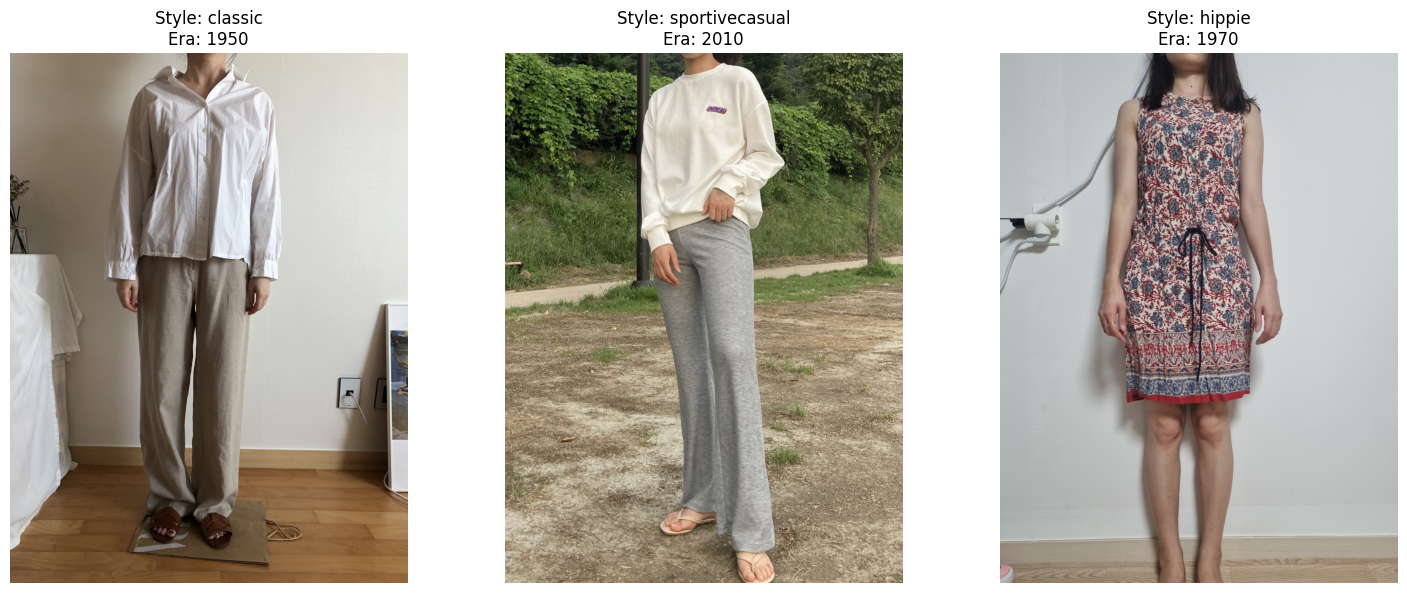

In [43]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

if recommendations_new:
    # 1행 3열(추천 개수)로 이미지 시각화
    fig, axes = plt.subplots(1, len(recommendations_new), figsize=(15, 6))
    if len(recommendations_new) == 1:
        axes = [axes]

    for ax, rec in zip(axes, recommendations_new):
        img_name = rec['imgName']
        img_path = find_image_path(img_name, base_search_path)

        if img_path:
            img = mpimg.imread(img_path)
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(f"Style: {rec['style']}\nEra: {rec['era']}", fontsize=12)
        else:
            ax.text(0.5, 0.5, 'Image Not Found', ha='center', va='center', fontsize=12, color='red')
            ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("표시할 추천 이미지가 없습니다.")

## 클러스터링 시각화

In [33]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 군집화에 사용할 특성(설문 응답) 선택
survey_cols = [col for col in df.columns if 'Q42' in col]
print(f"사용된 설문 특성 개수: {len(survey_cols)}개")

# 2. 결측치 처리 및 데이터 추출
cluster_data = df[survey_cols].fillna(0)

# 3. 데이터 스케일링
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# 4. K-Means 클러스터링 (예: 4개의 페르소나 그룹)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['persona_cluster'] = kmeans.fit_predict(scaled_data)

print(f"\n✅ 클러스터링 완료! (총 {n_clusters}개의 페르소나 그룹)")
display(df['persona_cluster'].value_counts().sort_index())

사용된 설문 특성 개수: 16개

✅ 클러스터링 완료! (총 4개의 페르소나 그룹)


,count
persona_cluster,
0,9748
1,10085
2,4770
3,3862


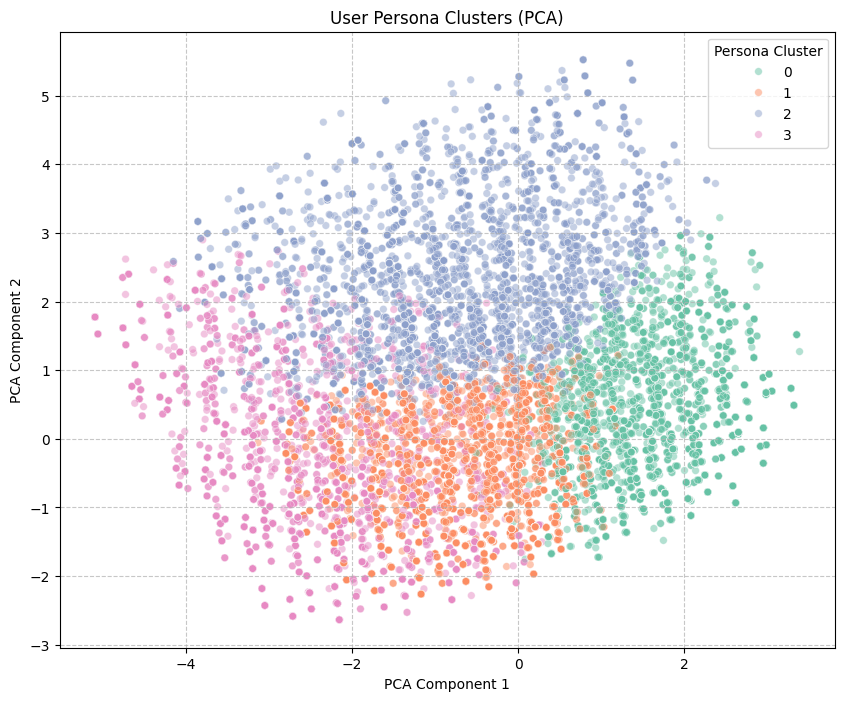

In [34]:
from sklearn.decomposition import PCA

# 5. 차원 축소를 통한 시각화 (PCA)
# 고차원의 설문 데이터를 2차원으로 축소하여 산점도로 표현
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_data)

df['pca_x'] = pca_features[:, 0]
df['pca_y'] = pca_features[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='pca_x', y='pca_y',
    hue='persona_cluster',
    palette='Set2',
    data=df,
    alpha=0.5,
    s=30
)
plt.title('User Persona Clusters (PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Persona Cluster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

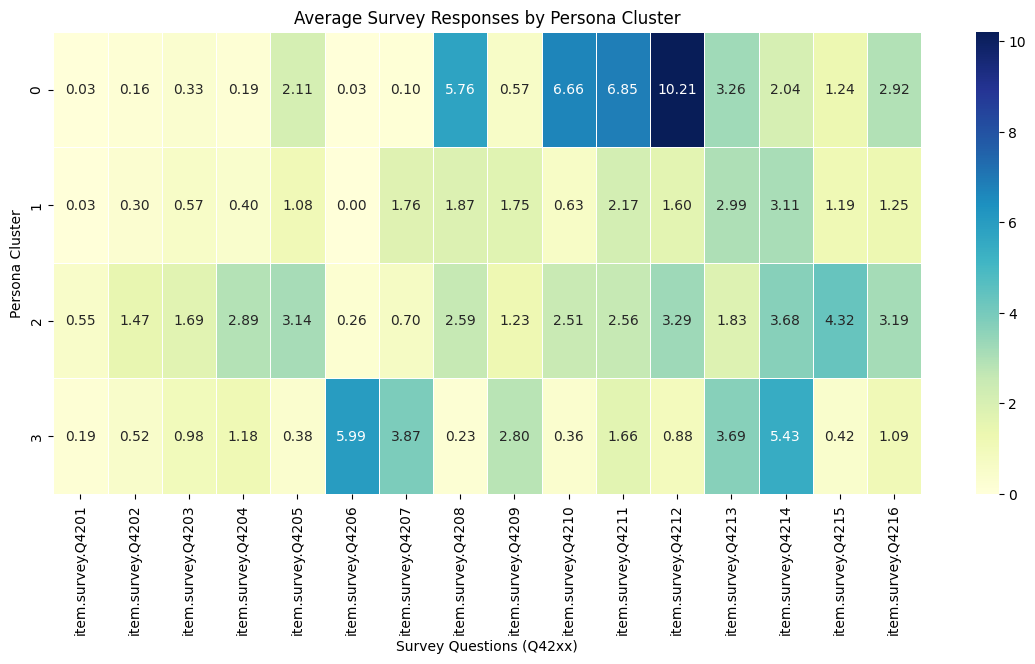

=== 클러스터별 주요 특성 (평균 점수가 가장 높은 상위 3개 문항) ===

[Cluster 0]
  - item.survey.Q4212: 10.21
  - item.survey.Q4211: 6.85
  - item.survey.Q4210: 6.66

[Cluster 1]
  - item.survey.Q4214: 3.11
  - item.survey.Q4213: 2.99
  - item.survey.Q4211: 2.17

[Cluster 2]
  - item.survey.Q4215: 4.32
  - item.survey.Q4214: 3.68
  - item.survey.Q4212: 3.29

[Cluster 3]
  - item.survey.Q4206: 5.99
  - item.survey.Q4214: 5.43
  - item.survey.Q4207: 3.87


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 클러스터별 설문 문항(Q42xx) 평균 계산
cluster_means = df.groupby('persona_cluster')[survey_cols].mean()

# 2. 히트맵으로 시각화
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_means, cmap='YlGnBu', annot=True, fmt=".2f", linewidths=.5)
plt.title('Average Survey Responses by Persona Cluster')
plt.xlabel('Survey Questions (Q42xx)')
plt.ylabel('Persona Cluster')
plt.show()

# 3. 클러스터별 주요 특성 텍스트 출력
print("=== 클러스터별 주요 특성 (평균 점수가 가장 높은 상위 3개 문항) ===")
for cluster_id in range(n_clusters):
    top_features = cluster_means.loc[cluster_id].sort_values(ascending=False).head(3)
    print(f"\n[Cluster {cluster_id}]")
    for col, val in top_features.items():
        print(f"  - {col}: {val:.2f}")